In [29]:
import numpy as np
import matplotlib.pyplot as plt
#!pip install scipy
from scipy import stats
from scipy import optimize

### Assumptions of this model:
- ### All the quantities are **fixed** and don't vary with time.
- ### Ad's quality $q_a$ and profit-per-click $v_a$ don't depend on the slot.
- ### Prominence $\lambda_s$ doesn't depend on the ad.

In [30]:
class Auction:
    def __init__(self, *args, **kwargs):
        pass

    def get_winners(self, bids):
        pass

    def get_payments_per_click(self, winners, bids):
        pass

    def round(self, bids):
        winners = self.get_winners(bids) # allocation mechanism!
        payments_per_click = self.get_payments_per_click(winners, bids)
        return winners, payments_per_click

In [31]:
class FirstPriceAuction(Auction):
    def __init__(self, qs):
        self.qs = qs
        self.n_adv = len(self.qs)
    
    def get_winners(self, bids):
        public_values = self.qs*bids
        public_ranking = np.argsort(public_values)
        winner = public_ranking[-1] # <--------------------- The only difference with second price auction implementation
        return winner
    
    def get_payments_per_click(self, winners, bids):
        payment = bids[winners]
        return payment

Let's formalize the dynamics as follows, for each round $t \in [T]$:

1. You choose a bid $b_t \in [0,1]$ at time $t$.
2. The competition's highest bid $m_t$ is realized.
3. If $b_t \geq m_t$, you win and get utility

$$
f_t(b_t) = v - b_t,
$$

and pay a cost equal to the proposed bid $b_t$. Otherwise, both are $0$. We assumed from now on that $q_s*\lambda_s=1$ (CTR=1)

In [32]:
# advertisers' fixed parameters
n_adv = 4 # four advertisers
qs = np.array([1, 1, 1, 1]) # quality scores
v = np.array([0.7, 1.1, 1.4, 0.85]) # valuations
possible_bids_space = np.linspace(0.05, 1, 20) # possible bids space

print(f'Possible bids space: {possible_bids_space}')

assert len(qs) == n_adv
assert len(v) == n_adv

# environmental settings
n_users= 3

auction = FirstPriceAuction(qs=qs)
for u in range(n_users):
    print(f'# User {u}')
    bids = np.random.choice(possible_bids_space, size=n_adv)
    pub_values = bids*qs
    print(f'Bids: {bids}, Publisher Values: {pub_values}')
    winner, payment_per_click = auction.round(bids=bids)
    utility = np.zeros(n_adv)
    utility[winner] = v[winner] - payment_per_click
    print(f'Auction Winner: {winner}, Payment-per-click: {payment_per_click}')
    print(f'Utilities: {utility}')
    print(f'Payment == Bid : {payment_per_click == bids[winner]}')

Possible bids space: [0.05 0.1  0.15 0.2  0.25 0.3  0.35 0.4  0.45 0.5  0.55 0.6  0.65 0.7
 0.75 0.8  0.85 0.9  0.95 1.  ]
# User 0
Bids: [0.95 0.55 0.3  0.7 ], Publisher Values: [0.95 0.55 0.3  0.7 ]
Auction Winner: 0, Payment-per-click: 0.95
Utilities: [-0.25  0.    0.    0.  ]
Payment == Bid : True
# User 1
Bids: [0.5  0.8  0.6  0.45], Publisher Values: [0.5  0.8  0.6  0.45]
Auction Winner: 1, Payment-per-click: 0.7999999999999999
Utilities: [0.  0.3 0.  0. ]
Payment == Bid : True
# User 2
Bids: [0.7 0.9 1.  0.8], Publisher Values: [0.7 0.9 1.  0.8]
Auction Winner: 2, Payment-per-click: 1.0
Utilities: [0.  0.  0.4 0. ]
Payment == Bid : True


The idea in the previous code is just showcasing that there 4 bids, therefore i=4, and maken them to play the first price auction and win the ones always who bidf the highest. In this case we are not imposing the case where $b_t>v_i$ for each $i$, so we could get negatives. This is just exploratory.

## Advertiser's Perspective: learning in repeated first price auctions

### We assume from now on that all CTRs are equal to 1
## Stochatic setting

C:\Users\Recup\AppData\Local\Temp\ipykernel_53384\3216493127.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


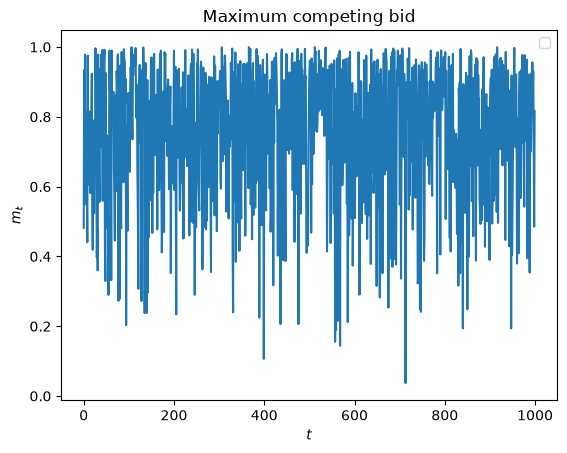

In [33]:
### Stochastic Bidders: my competitors sample their bids from 
### probability distributions

n_advertisers = 3
n_users = 1000 #T-rounds
B = 150
my_valuation = 0.6
rho = B/n_users

# simple scenario: competitors sample bids from a uniform 
other_bids = np.random.uniform(0, 1, size = (n_advertisers, n_users))
# I assume that competitors may have a larger budget than mine, but they may
# not deplete it.
m_t = other_bids.max(axis=0)

plt.title("Maximum competing bid")
plt.plot(m_t)
plt.xlabel('$t$')
plt.ylabel('$m_t$')
plt.legend()
plt.show()

This code generates the realized maximum competing bid for each round.

### When the competing bids are $b_i \sim U([0,1]), i=1,\dots,k$,  the maximum is $m_t \sim Beta(k,1)$. **We will assume this model now.**

Possible bids space: [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]


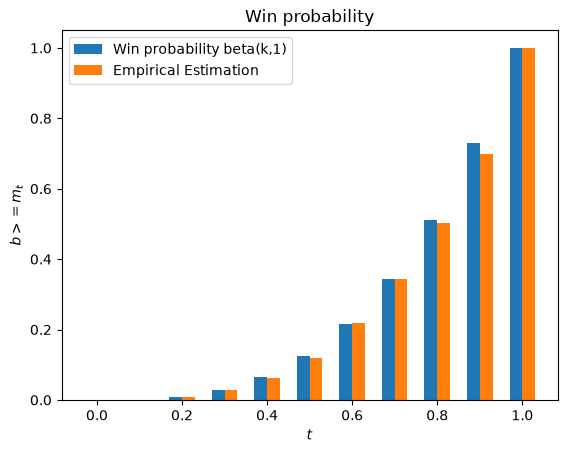

In [34]:
### the maximum among k uniformly distributed r.v.s is a beta r.v. with alpha=k and beta=1
available_bids = np.linspace(0,1,11)
print(f'Possible bids space: {available_bids}')

# This functions recieve a array of possible bids and return the beta(n_advertisers, 1) CDF evaluated 
# at those bids. This is the theoretical win probability of a bid b >= m_t

win_probabilities = stats.beta.cdf(available_bids, n_advertisers, 1)

emp_win_probabilities = np.array([np.sum(b >= m_t) for b in available_bids])/len(m_t)

plt.title("Win probability")
width = 0.03
plt.bar(available_bids -width/2, win_probabilities, width=width, align='center', label='Win probability beta(k,1)')
plt.bar(available_bids +width/2, emp_win_probabilities, width=width, align='center', label='Empirical Estimation')
plt.xlabel('$t$')
plt.ylabel('$b >= m_t$')
plt.legend()
plt.show()

# Witouth Budget

## What's the baseline (the clairvoyant)?

Without the budget constraint (UCB1 ignoring budget) we will have the (Bernoulli-like) realized reward of playing bid $b$ you get $v-b$ if you win the auction, $0$ otherwise.

$$
r(b) = (v-b)\cdot\mathbb{1}\{b \geq m_t\}
$$

and 
$$
\mu(b) = \mathbb{E}_{m_t}[r(b)] = (v-b)\,\mathbb{P}(b \geq m_t)
$$

is exactly the $\mathbb{E}[f(b)]$. Now lets calculate the optimal arm $b^*$

$$
b^\star \in \arg\max_{b \in \mathcal{B}} \mu(b)
$$

Using appendix proof, we can determine that in this case $F_{\text{Beta}(k,1)}(b) = b^k$. 

**Determine the General Formula for the optimum**


So to estimate the general closed-form solution (continuous bid space $b \in [0,1]$, competing
bids $m_t \sim \text{Beta}(k,1)$, so $\mathbb{P}(b \geq m_t) = b^k$):

$$
\mu(b) =  \mathbb{E}_{m_t}[r(b)] = (v-b)\,\mathbb{P}(b \geq m_t)=(v-b)\,b^k
$$

Differentiate w.r.t. $b$ and set to zero:

$$
\mu'(b) = -b^k + k(v-b)\,b^{k-1} = b^{k-1}\big[k v - (k+1) b\big]
$$

$$
\mu'(b) = 0 \;\;\Longrightarrow\;\; b^\star = \frac{k}{k+1}\,v
$$

(the other root $b=0$ is a minimum, and $\mu'(b)>0$ for $b<b^\star$,
$\mu'(b)<0$ for $b>b^\star$, confirming this is the unique maximum.)

In [35]:
# Continuous optimal bid: b* = k/(k+1) * v
optimal_bid = (n_advertisers / (n_advertisers + 1)) * my_valuation

# Expected reward for every available bid arm
win_probabilities = available_bids ** n_advertisers
expected_rewards = (my_valuation - available_bids) * win_probabilities

print(f'Optimal bid: {optimal_bid:.4f}')

Optimal bid: 0.4500


Now we know the best bid, but since we discretized over some possible arms (possible bids) we need to select the closest one

In [36]:
# Select the arm closest to the continuous optimum
closest_arm_index = np.argmin(np.abs(available_bids - optimal_bid))
closest_arm = available_bids[closest_arm_index]
closest_arm_reward = expected_rewards[closest_arm_index]

print(f"Closest available arm: {closest_arm:.4f}")
print(f"Expected reward for closest arm: {closest_arm_reward:.4f}")


Closest available arm: 0.4000
Expected reward for closest arm: 0.0128


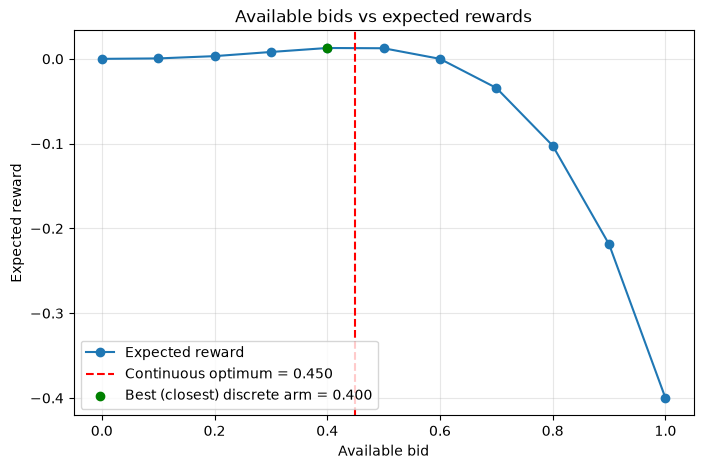

In [37]:
plt.figure(figsize=(8, 5))
plt.plot(available_bids, expected_rewards, marker='o', label='Expected reward')
plt.axvline(optimal_bid, color='red', linestyle='--',
            label=f'Continuous optimum = {optimal_bid:.3f}')
plt.scatter(closest_arm, closest_arm_reward, color='green', zorder=3,
            label=f'Best (closest) discrete arm = {closest_arm:.3f}')
plt.xlabel('Available bid')
plt.ylabel('Expected reward')
plt.title('Available bids vs expected rewards')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

Now we implement the UCB Witouth Budget Learner

In [38]:
class UCB1AuctionAgent:
    def __init__(self, available_bids, valuation, T, reward_range=1):
        self.available_bids = np.array(available_bids)
        self.valuation = valuation
        self.K = len(self.available_bids)
        self.T = T
        self.reward_range = reward_range

        self.arm = None
        self.t = 0
        self.N_pulls = np.zeros(self.K)
        self.average_rewards = np.zeros(self.K)

    def pull_arm(self):
        # Explore every arm once
        if self.t < self.K:
            self.arm = self.t
        else:
            confidence_bonus = self.reward_range * np.sqrt(
                2 * np.log(self.T) / self.N_pulls
            )
            ucbs = self.average_rewards + confidence_bonus
            self.arm = np.argmax(ucbs)

        return self.arm

    def update(self, reward):
        self.N_pulls[self.arm] += 1

        self.average_rewards[self.arm] += (
            reward - self.average_rewards[self.arm]
        ) / self.N_pulls[self.arm]

        self.t += 1

In [39]:
agent = UCB1AuctionAgent(
    available_bids=available_bids,
    valuation=my_valuation,
    T=n_users
)

selected_bids = []
observed_rewards = []

for t in range(n_users):
    # Select an arm index and obtain the corresponding bid
    arm = agent.pull_arm()
    bid = available_bids[arm]

    # Win if our bid is at least the highest competing bid
    win = bid >= m_t[t]

    # CTR = 1, so reward is valuation minus bid if we win
    reward = (my_valuation - bid) * int(win)

    # Update the UCB statistics
    agent.update(reward)

    selected_bids.append(bid)
    observed_rewards.append(reward)

selected_bids = np.array(selected_bids)
observed_rewards = np.array(observed_rewards)

print(f"Number of pulls per arm: {agent.N_pulls}")
print(f"Estimated reward per arm: {agent.average_rewards}")
print(f"Total reward: {observed_rewards.sum():.4f}")

Number of pulls per arm: [108. 108. 110. 114. 114. 114. 107.  89.  67.  45.  24.]
Estimated reward per arm: [ 0.00000000e+00  0.00000000e+00  3.63636364e-03  1.05263158e-02
  1.05263158e-02  1.05263158e-02 -2.28270155e-17 -3.48314607e-02
 -9.55223881e-02 -2.00000000e-01 -4.00000000e-01]
Total reward: -24.1000


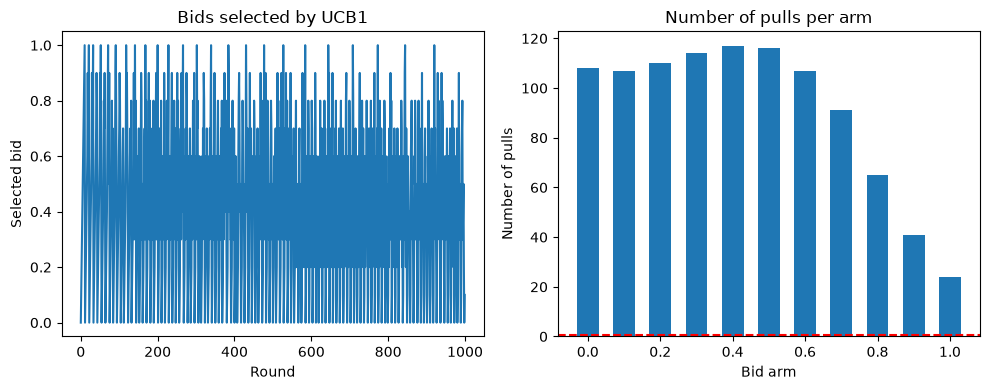

In [46]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(selected_bids)
plt.xlabel("Round")
plt.ylabel("Selected bid")
plt.title("Bids selected by UCB1")

plt.subplot(1, 2, 2)
plt.bar(available_bids, agent.N_pulls, width=0.06)
plt.xlabel("Bid arm")
plt.ylabel("Number of pulls")
plt.title("Number of pulls per arm")

plt.axhline(
    optimal_bid,
    color="red",
    linestyle="--",
    label=f"Continuous optimum = {optimal_bid:.3f}"
)
plt.tight_layout()
plt.show()

We see the bid arm select the closest arms 0.4 and 0.5. So its learning. Now we run different trials

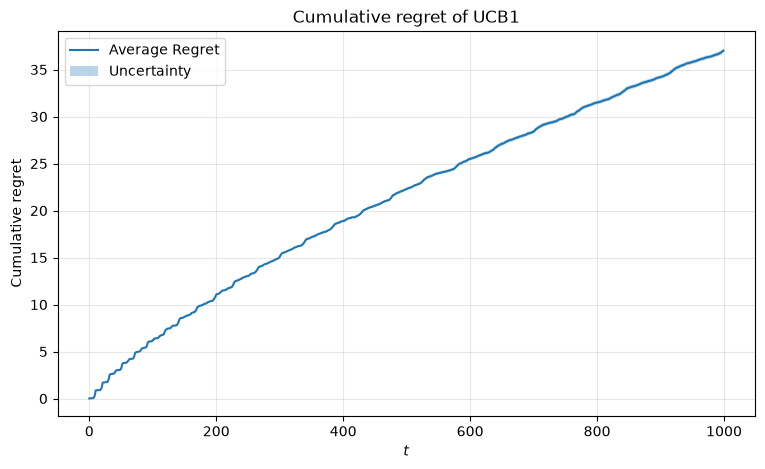

Clairvoyant best bid: 0.40
Average final regret: 37.0067


In [ ]:
# Cumulative regret with uncertainty

T = n_users
K = len(available_bids)
k = n_advertisers

n_trials = 30

# Expected reward of each bid arm
win_probabilities = available_bids ** k
expected_rewards = (
    my_valuation - available_bids
) * win_probabilities

# Best discrete arm for the clairvoyant
best_action = np.argmax(expected_rewards)

# Expected clairvoyant reward at every round
expected_clairvoyant_rewards = np.repeat(
    expected_rewards[best_action],
    T
)

regret_per_trial = []

for seed in range(n_trials):
    np.random.seed(seed)

    # Generate competing bids for this trial
    other_bids = np.random.uniform(
        0,
        1,
        size=(k, T)
    )

    # Highest competing bid at every round
    m_t = other_bids.max(axis=0)

    agent = UCB1AuctionAgent(
        available_bids=available_bids,
        valuation=my_valuation,
        T=T
    )

    agent_rewards = np.array([])

    for t in range(T):
        # Select an arm and obtain the corresponding bid
        arm = agent.pull_arm()
        bid = available_bids[arm]

        # Realized auction reward
        win = bid >= m_t[t]
        reward = (my_valuation - bid) * int(win)

        # Update UCB1
        agent.update(reward)

        agent_rewards = np.append(
            agent_rewards,
            reward
        )

    # Cumulative pseudo-regret
    cumulative_regret = np.cumsum(
        expected_clairvoyant_rewards - agent_rewards
    )

    regret_per_trial.append(cumulative_regret)


# Calculating Trial Metrics

regret_per_trial = np.array(regret_per_trial)

# Average regret and uncertainty
average_regret = regret_per_trial.mean(axis=0)
regret_sd = regret_per_trial.std(axis=0)
standard_error = regret_sd / np.sqrt(n_trials)

# Plot cumulative regret
time = np.arange(T)

plt.figure(figsize=(9, 5))

plt.plot(
    time,
    average_regret,
    label="Average Regret"
)

plt.fill_between(
    time,
    average_regret - standard_error,
    average_regret + standard_error,
    alpha=0.3,
    label="Uncertainty"
)

plt.xlabel("$t$")
plt.ylabel("Cumulative regret")
plt.title("Cumulative regret of UCB1")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(
    f"Clairvoyant best bid: "
    f"{available_bids[best_action]:.2f}"
)

print(
    f"Average final regret: "
    f"{average_regret[-1]:.4f}"
)

## Appendix Proof 

Derivation from the Beta PDF. The general Beta$(\alpha,\beta)$ density is

$$
f(x) = \frac{x^{\alpha-1}(1-x)^{\beta-1}}{B(\alpha,\beta)}, \qquad x \in [0,1]
$$

where $B(\alpha,\beta) = \dfrac{\Gamma(\alpha)\Gamma(\beta)}{\Gamma(\alpha+\beta)}$. Setting $\beta = 1$:

$$
B(\alpha,1) = \frac{\Gamma(\alpha)\Gamma(1)}{\Gamma(\alpha+1)} = \frac{\Gamma(\alpha)}{\alpha\,\Gamma(\alpha)} = \frac{1}{\alpha}
$$

(using $\Gamma(\alpha+1) = \alpha\Gamma(\alpha)$ and $\Gamma(1)=1$), so the density simplifies to $f(x) = \alpha\, x^{\alpha-1}$. Integrating to get the CDF:

$$
F(x) = \int_0^x \alpha\, t^{\alpha-1}\,dt = x^\alpha
$$

Setting $\alpha = k$ gives exactly $F_{\text{Beta}(k,1)}(b) = b^k$.